# Test Fox (fox.ckpt)

Evaluates the released checkpoint `fox.ckpt` on the 40 simulated test datasets in `test_data/fox_data/`,
pre-encoded with `training/pre_encoder.py` exactly as the training data (lost-gene leaves and the planted
root row dropped, protein Jukes-Cantor distances), then compares it with the previous model in `old/`
and runs the *Heliconius* real-data test.

Pre-encode (from the repo root):
`python training/pre_encoder.py --src test_data/Datasets --dst test_data/fox_data`

In [1]:
import sys, os, glob
import numpy as np, pandas as pd, torch

from training.model import Fox

CKPT_PATH = "fox.ckpt"
DATA_DIR  = "test_data/fox_data"
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EVENT_NAMES = ["Speciation", "HGT", "Loss", "Duplication"]
EVENT_LABELS = {"Speciation": "Cospeciation", "HGT": "Host switch", "Loss": "Loss", "Duplication": "Duplication"}
def disp(e): return EVENT_LABELS.get(e, e)

ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
hp   = ckpt["hparams"]
num_cross_layers = max(int(k.split(".")[1]) for k in ckpt["model"] if k.startswith("pair_blocks.")) + 1
model = Fox(
    hidden_dim=hp.get("hidden_dim", 256), pair_dim=hp.get("pair_dim", 64), num_heads=8,
    axial_layers=hp["axial_layers"], use_opm=hp.get("use_opm", False), use_dist_matrix=True,
    gradient_checkpointing=False, num_cross_layers=num_cross_layers, cls_dim=hp.get("cls_dim", 512),
    use_flexattention=False, dropout=0.0,
)
model.load_state_dict(ckpt["model"])
model.to(device).eval()
print(f"Loaded {CKPT_PATH}: epoch {ckpt['epoch'] + 1}, val loss {ckpt['val_loss']:.6f}, "
      f"axial={hp['axial_layers']}, cross={num_cross_layers}")

Loaded fox.ckpt: epoch 18, val loss 0.004172, axial=2, cross=2


In [2]:
# -- Predict on the pre-encoded test set (same .pt format as training) --
rows = []
with torch.no_grad():
    for path in sorted(glob.glob(f"{DATA_DIR}/*.pt")):
        s = torch.load(path, map_location="cpu", weights_only=False)
        out = model(
            s["host_msa"].unsqueeze(0).to(device), s["para_msa"].unsqueeze(0).to(device), [s["mappings"]],
            host_dist=s["host_dist"].unsqueeze(0).to(device), para_dist=s["para_dist"].unsqueeze(0).to(device),
        ).squeeze(0).cpu().tolist()
        rows.append({"file": os.path.basename(path),
                     "host_leaves": s["host_msa"].shape[0], "para_leaves": s["para_msa"].shape[0],
                     **{f"true_{e}": s["labels"][e] for e in EVENT_NAMES},
                     **{f"pred_{e}": p for e, p in zip(EVENT_NAMES, out)}})
df = pd.DataFrame(rows)
print(f"{len(df)} datasets")
df.head()

40 datasets


,file,host_leaves,para_leaves,true_Speciation,true_HGT,true_Loss,true_Duplication,pred_Speciation,pred_HGT,pred_Loss,pred_Duplication
0,0000000.pt,38,58,0.8276,0.0517,0.0172,0.1034,0.734398,0.050179,0.079253,0.136170
1,0000001.pt,38,66,0.6667,0.1014,0.0580,0.1739,0.596575,0.103778,0.076224,0.223423
2,0000002.pt,30,37,0.7568,0.1081,0.0270,0.1081,0.706190,0.104996,0.051222,0.137592
3,0000003.pt,30,77,0.5909,0.1591,0.1364,0.1136,0.560761,0.182046,0.142021,0.115172
4,0000004.pt,30,86,0.5591,0.1613,0.0860,0.1935,0.479833,0.195926,0.136831,0.187410


In [3]:
from sklearn.metrics import r2_score

metrics = []
for e in EVENT_NAMES:
    t, p = df[f"true_{e}"], df[f"pred_{e}"]
    base = np.abs(t - t.mean()).mean()
    metrics.append({"Event": disp(e), "MAE": np.abs(p - t).mean(), "MAE (predict mean)": base,
                    "R²": r2_score(t, p), "Bias": (p - t).mean()})
pd.DataFrame(metrics).set_index("Event").round(4)

,MAE,MAE (predict mean),R²,Bias
Event,,,,
Cospeciation,0.0499,0.0741,0.5713,0.0145
Host switch,0.0196,0.0393,0.7038,-0.0083
Loss,0.0304,0.0425,0.4874,-0.0106
Duplication,0.0189,0.0336,0.6210,0.0043


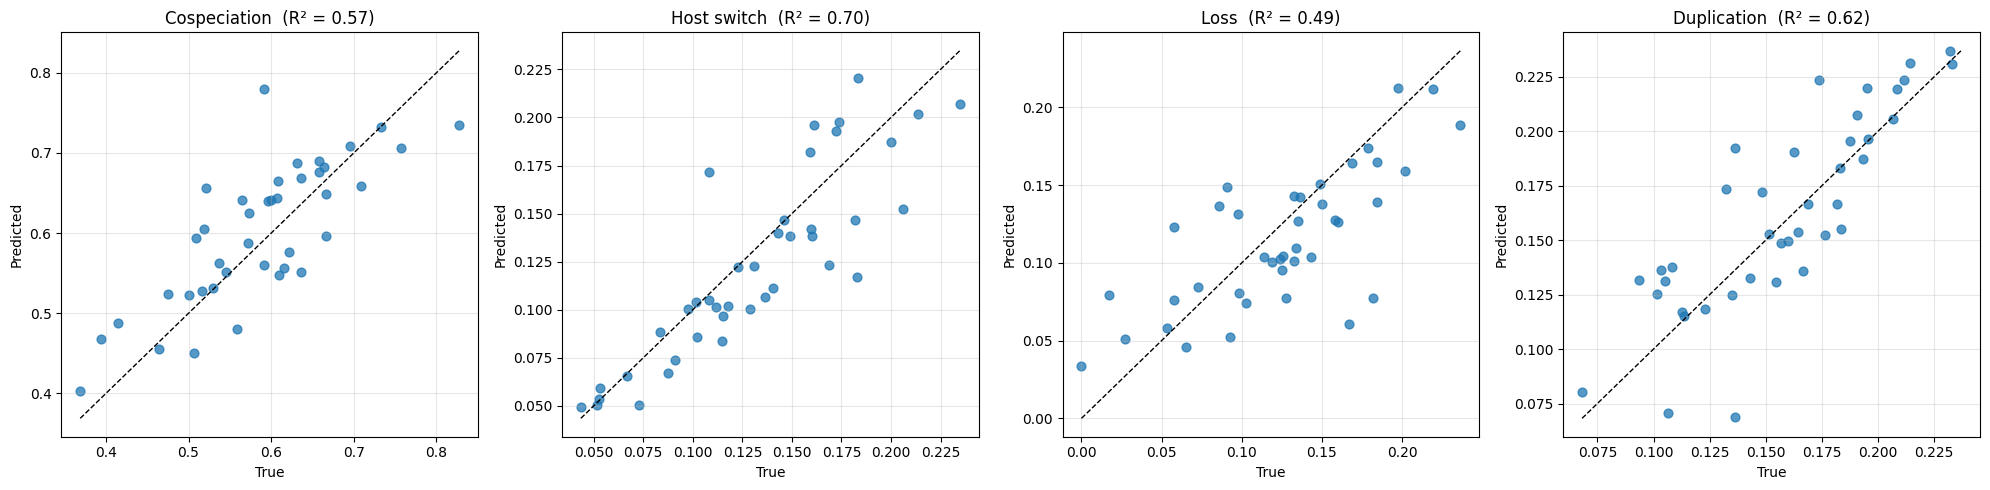

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, e in zip(axes, EVENT_NAMES):
    t, p = df[f"true_{e}"], df[f"pred_{e}"]
    ax.scatter(t, p, s=40, alpha=0.75)
    lo, hi = min(t.min(), p.min()), max(t.max(), p.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set(title=f"{disp(e)}  (R² = {r2_score(t, p):.2f})", xlabel="True", ylabel="Predicted")
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Real data: Heliconius (no lost-leaf dropping on real data)

The original file is mitochondrial DNA (COI + COII). Fox reads amino acids, so it is translated first (invertebrate mitochondrial code, frame picked automatically):
`python -m fox.translate test_data/real_data/heliconius_mimicry.tgl test_data/real_data/heliconius_mimicry_aa.tgl --table 5`

Caveat: at the protein level these sequences are almost identical (host: 1 variable column in the first 250), so there is very little signal for Fox here.

In [5]:
from fox.io import read_tgl
from fox.encoding import encode_msa, jukes_cantor_dist

h = read_tgl("test_data/real_data/heliconius_mimicry_aa.tgl")
h_tok, s_tok = encode_msa(h["host_msa"]), encode_msa(h["sym_msa"])
h_idx = {n: i for i, n in enumerate(h["host_msa"])}
s_idx = {n: i for i, n in enumerate(h["sym_msa"])}
maps  = [(h_idx[a], s_idx[b]) for a, b in h["mapping"] if a in h_idx and b in s_idx]
with torch.no_grad():
    out = model(h_tok.unsqueeze(0).to(device), s_tok.unsqueeze(0).to(device), [maps],
                host_dist=jukes_cantor_dist(h_tok).unsqueeze(0).to(device),
                para_dist=jukes_cantor_dist(s_tok).unsqueeze(0).to(device)).squeeze(0).cpu().tolist()
pd.Series(dict(zip(map(disp, EVENT_NAMES), out)), name="fox.ckpt").round(4)

Cospeciation    0.3596
Host switch     0.0965
Loss            0.2144
Duplication     0.3295
Name: fox.ckpt, dtype: float64

## Comparison with the previous model (old/fox.ckpt)

The previous model (`old/fox.ckpt`, code in `old/training/` and `old/fox/`) was trained with lost-gene leaves
and the root row kept, and 4-state Jukes-Cantor distances. It is scored on the same 40 datasets in
two ways:

- **native**: its own preprocessing, lost-gene leaves included. Optimistic: real data never has
  sequences for lost genes.
- **no lost leaves**: lost-gene leaves and root row dropped, as in real data (same leaves the new
  model sees), with its own 4-state distances. This is the fair comparison.

In [6]:
import importlib.util
from fox.io import read_tgl as read_tgl_new

def _load_file(name, path):
    # old/ modules are loaded under their own names, so they do not clash with the current package
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec); sys.modules[name] = mod
    spec.loader.exec_module(mod); return mod

FoxOld  = _load_file("old_training_model", "old/training/model.py").Fox
enc_old = _load_file("old_fox_encoding", "old/fox/encoding.py")
read_tgl_old = _load_file("old_fox_io", "old/fox/io.py").read_tgl

OLD_CKPT = "old/fox.ckpt"
TGL_DIR  = "test_data/Datasets"

ck_old = torch.load(OLD_CKPT, map_location="cpu", weights_only=False)
hp_old = ck_old.get("hparams", {})
model_old = FoxOld(
    hidden_dim=256, pair_dim=hp_old.get("pair_dim", 64), num_heads=8,
    axial_layers=hp_old.get("axial_layers", 2), use_opm=hp_old.get("use_opm", False),
    use_dist_matrix=True, gradient_checkpointing=False,
    num_cross_layers=max(int(k.split(".")[1]) for k in ck_old["model"] if k.startswith("cross_attn_h2p.")) + 1,
    cls_dim=hp_old.get("cls_dim", 512), use_flexattention=False, dropout=0.0,
)
model_old.load_state_dict(ck_old["model"])
model_old.to(device).eval()

def predict_old(host_msa, sym_msa, mapping):
    ht, st = enc_old.encode_msa(host_msa), enc_old.encode_msa(sym_msa)
    hi = {n: i for i, n in enumerate(host_msa)}
    si = {n: i for i, n in enumerate(sym_msa)}
    maps = [(hi[h], si[s]) for h, s in mapping if h in hi and s in si]
    with torch.no_grad():
        out = model_old(ht.unsqueeze(0).to(device), st.unsqueeze(0).to(device), [maps],
                        host_dist=enc_old.jukes_cantor_dist(ht).unsqueeze(0).to(device),
                        para_dist=enc_old.jukes_cantor_dist(st).unsqueeze(0).to(device))
    return dict(zip(EVENT_NAMES, out.squeeze(0).cpu().tolist()))

# pre_encoder numbered the .pt files in sorted .tgl order, so row i of df is the i-th sorted .tgl
tgl_files = sorted(glob.glob(f"{TGL_DIR}/*.tgl"))
assert len(tgl_files) == len(df)
for i, f in enumerate(tgl_files):
    d_nat  = read_tgl_old(f)                     # lost leaves + root row kept
    d_real = read_tgl_new(f, drop_lost=True)     # what real data shows
    assert all(abs(d_real["labels"][e] - df.at[i, f"true_{e}"]) < 1e-6 for e in EVENT_NAMES)
    for e, v in predict_old(d_nat["host_msa"], d_nat["sym_msa"], d_nat["mapping"]).items():
        df.at[i, f"oldnat_{e}"] = v
    for e, v in predict_old(d_real["host_msa"], d_real["sym_msa"], d_real["mapping"]).items():
        df.at[i, f"oldreal_{e}"] = v

MODELS = {"new (fox.ckpt)": "pred", "old, no lost leaves": "oldreal", "old, native": "oldnat"}
cmp = []
for e in EVENT_NAMES:
    t = df[f"true_{e}"]
    for name, col in MODELS.items():
        p = df[f"{col}_{e}"]
        cmp.append({"Event": disp(e), "Model": name, "MAE": np.abs(p - t).mean(),
                    "R²": r2_score(t, p), "Bias": (p - t).mean()})
pd.DataFrame(cmp).set_index(["Event", "Model"]).round(4)

MAE      R²    Bias
Event        Model                                      
Cospeciation new (fox.ckpt)       0.0499  0.5713  0.0145
             old, no lost leaves  0.1099 -0.8385  0.1072
             old, native          0.0242  0.8870  0.0029
Host switch  new (fox.ckpt)       0.0196  0.7038 -0.0083
             old, no lost leaves  0.0280  0.4472 -0.0144
             old, native          0.0256  0.5138 -0.0104
Loss         new (fox.ckpt)       0.0304  0.4874 -0.0106
             old, no lost leaves  0.0905 -2.6240 -0.0893
             old, native          0.0157  0.8585 -0.0041
Duplication  new (fox.ckpt)       0.0189  0.6210  0.0043
             old, no lost leaves  0.0289  0.0885 -0.0035
             old, native          0.0264  0.3259  0.0116

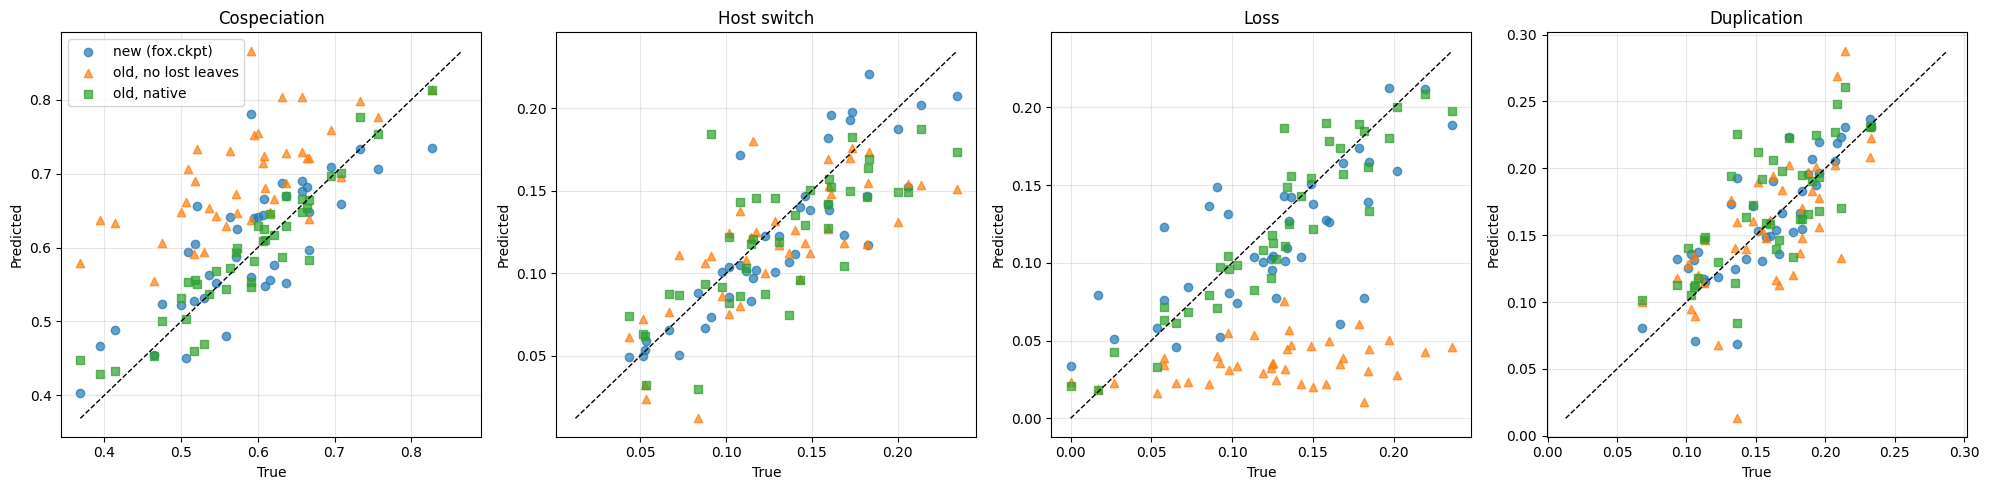

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
styles = {"pred": ("C0", "o"), "oldreal": ("C1", "^"), "oldnat": ("C2", "s")}
for ax, e in zip(axes, EVENT_NAMES):
    t = df[f"true_{e}"]
    for name, col in MODELS.items():
        c, mk = styles[col]
        ax.scatter(t, df[f"{col}_{e}"], s=36, alpha=0.7, color=c, marker=mk, label=name)
    vals = pd.concat([t] + [df[f"{col}_{e}"] for col in MODELS.values()])
    ax.plot([vals.min(), vals.max()], [vals.min(), vals.max()], "k--", lw=1)
    ax.set(title=disp(e), xlabel="True", ylabel="Predicted")
    ax.grid(True, alpha=0.3)
axes[0].legend()
fig.tight_layout()
plt.show()

In [8]:
# -- Heliconius: both models (real data, nothing to drop) --
h_old = read_tgl_old("test_data/real_data/heliconius_mimicry_aa.tgl")
pd.DataFrame({
    "new (fox.ckpt)": dict(zip(EVENT_NAMES, out)),
    "old (old/fox.ckpt)":     predict_old(h_old["host_msa"], h_old["sym_msa"], h_old["mapping"]),
}).rename(index=disp).round(4)

,new (fox.ckpt),old (old/fox.ckpt)
Cospeciation,0.3596,0.7230
Host switch,0.0965,0.0152
Loss,0.2144,0.0130
Duplication,0.3295,0.2488


## Real data: cockroaches and *Blattabacterium*

Arab et al. (2020, *Biol. Lett.* 16: 20190702; data Dryad doi:10.5061/dryad.v6wwpzgqw, CC0): 55 cockroach /
*Blattabacterium* pairs across all cockroach families. Amino-acid alignments of 13 mitochondrial proteins (host)
and 104 symbiont genes. The symbiont is passed from mother to offspring and the two trees are almost fully
congruent (ParaFit p = 0.001), so the expected answer is **mostly cospeciation**.

Unlike *Heliconius*, these alignments are divergent enough to be close to the training range (mean protein
distance about 0.5 host / 0.3 symbiont, vs 1.2 in training; about 60% variable columns). Three pairs with
ambiguous labels are dropped (52 left), and 50 are used because Fox takes at most 50 hosts.

Fox reads 250 amino acids, so it is run on several host and symbiont windows (with less than 10% gaps). As a
control, each run is repeated with the host-symbiont links scrambled: a model that uses the links should move
away from cospeciation.

In [9]:
# -- Build the pairs and pick windows --
import json, random, subprocess
BLAT = "test_data/real_data/blattabacterium"
if not os.path.exists(f"{BLAT}/pairs.json"):
    subprocess.run([sys.executable, "build.py"], cwd=BLAT, check=True)
blat = json.load(open(f"{BLAT}/pairs.json"))

from fox.encoding import encode_msa as enc_new_msa, jukes_cantor_dist as jc_new

def windows(msa, max_gap=0.10):
    L = len(next(iter(msa.values())))
    out = []
    for a in range(0, L - 249, 250):
        w = [s[a:a + 250] for s in msa.values()]
        gap = sum(s.count("-") + s.count("X") for s in w) / (len(w) * 250)
        if gap < max_gap:
            t = enc_new_msa({i: s for i, s in enumerate(w)}); D = jc_new(t)
            iu = torch.triu_indices(len(t), len(t), 1)
            out.append((a, D[iu[0], iu[1]].mean().item()))
    return out

hw = windows(blat["host"]); sw = windows(blat["sym"])
host_wins = [a for a, _ in hw][::2][:6]                                  # 6 host windows spread along the genes
sym_wins  = [a for a, _ in sorted(sw, key=lambda x: -x[1])[:6]]          # the 6 most divergent symbiont windows
rng = random.Random(1)
pairs50 = sorted(rng.sample([h for h, _ in blat["links"]], 50))
print(f"{len(hw)} host / {len(sw)} symbiont windows with <10% gaps; using host {host_wins}, symbiont {sym_wins}")

12 host / 137 symbiont windows with <10% gaps; using host [0, 500, 1000, 1500, 2000, 3000], symbiont [0, 29250, 33000, 4750, 3250, 10750]


In [10]:
# -- Run both models, real vs scrambled links --
def run_pair(mdl, enc, H, S, perm):
    ht, st = enc.encode_msa(H), enc.encode_msa(S)
    maps = [(i, perm[i]) for i in range(len(H))]
    with torch.no_grad():
        return mdl(ht[None].to(device), st[None].to(device), [maps],
                   host_dist=enc.jukes_cantor_dist(ht)[None].to(device),
                   para_dist=enc.jukes_cantor_dist(st)[None].to(device))[0].cpu().tolist()

import fox.encoding as enc_new
MODELS_BLAT = {"new (fox.ckpt)": (model, enc_new), "old (old/fox.ckpt)": (model_old, enc_old)}
rows = []
for a in host_wins:
    H = {n: blat["host"][n][a:a + 250] for n in pairs50}
    for b in sym_wins:
        S = {n: blat["sym"][n][b:b + 250] for n in pairs50}
        perms = [list(range(50))] + [rng.sample(range(50), 50) for _ in range(3)]
        for name, (mdl, enc) in MODELS_BLAT.items():
            for k, perm in enumerate(perms):
                p = run_pair(mdl, enc, H, S, perm)
                rows.append({"model": name, "links": "real" if k == 0 else "scrambled",
                             "host_win": a, "sym_win": b, **dict(zip(EVENT_NAMES, p))})
df_blat = pd.DataFrame(rows)

summary = df_blat.groupby(["model", "links"])[EVENT_NAMES].median().rename(columns=disp)
real = df_blat[df_blat.links == "real"].groupby(["model", "host_win", "sym_win"])[EVENT_NAMES].mean()
scr  = df_blat[df_blat.links == "scrambled"].groupby(["model", "host_win", "sym_win"])[EVENT_NAMES].mean()
change = (real - scr).abs().groupby("model").mean().rename(columns=disp)
print("Median prediction over window combinations:")
display(summary.round(3))
print("Mean |real - scrambled| per window combination (how much the links matter):")
change.round(3)

Median prediction over window combinations:


Cospeciation  Host switch   Loss  Duplication
model              links                                                   
new (fox.ckpt)     real              0.634        0.166  0.129        0.078
                   scrambled         0.470        0.219  0.195        0.112
old (old/fox.ckpt) real              0.943        0.021  0.003        0.038
                   scrambled         0.943        0.021  0.003        0.038

Mean |real - scrambled| per window combination (how much the links matter):


,Cospeciation,Host switch,Loss,Duplication
model,,,,
new (fox.ckpt),0.154,0.057,0.063,0.036
old (old/fox.ckpt),0.000,0.000,0.000,0.000


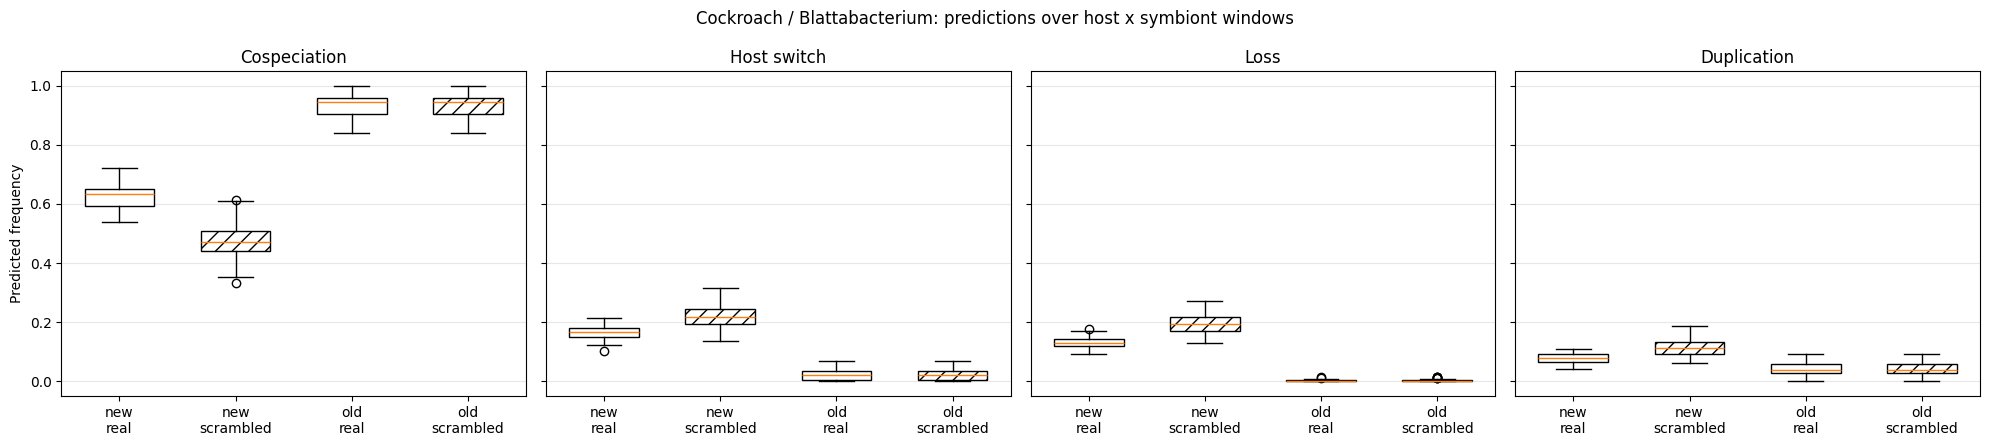

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
groups = [("new (fox.ckpt)", "real"), ("new (fox.ckpt)", "scrambled"),
          ("old (old/fox.ckpt)", "real"), ("old (old/fox.ckpt)", "scrambled")]
labels = ["new\nreal", "new\nscrambled", "old\nreal", "old\nscrambled"]
for ax, e in zip(axes, EVENT_NAMES):
    data = [df_blat[(df_blat.model == m) & (df_blat.links == l)][e] for m, l in groups]
    bp = ax.boxplot(data, patch_artist=True, widths=0.6)
    for patch, hatch in zip(bp["boxes"], ["", "//", "", "//"]):   # hatching: readable in B&W
        patch.set(facecolor="white", hatch=hatch)
    ax.set_xticks(range(1, 5), labels)
    ax.set_title(disp(e)); ax.grid(True, axis="y", alpha=0.3)
axes[0].set_ylabel("Predicted frequency")
fig.suptitle("Cockroach / Blattabacterium: predictions over host x symbiont windows")
fig.tight_layout()
plt.show()